# Unconstrained 2D potential ptychography at glancing incidence

This notebook reconstructs independent pixels of a finite two-dimensional electrostatic potential $V(s,u)$ from overlapping one-dimensional diffraction measurements. Propagation is along $s$, $u$ is transverse to the beam, and the physical silicon slab is flat and 50 Å deep.

There is no geometric surface parameterization, probe recovery, or lattice constraint in the inverse model. Only pixels reached by at least a configured fraction of the vacuum-probe intensity are optimized. Angular-spectrum propagation is used consistently for the forward model, reconstruction, and side views.

Full simulation, side-view caching, and reconstruction are opt-in because the matched atomistic experiment is intended for a GPU.

In [65]:
%matplotlib widget

from collections import OrderedDict
import importlib
import json
from pathlib import Path

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
from matplotlib.colors import PowerNorm
import matplotlib.pyplot as plt
import numpy as np

from wide_angle_propagation.notebook_utils import resolve_repo_root
import wide_angle_propagation.ptychography_1d as _ptychography_1d
importlib.reload(_ptychography_1d)
from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    angular_spectrum_propagation_kernel_1d,
    interaction_constant,
)
from wide_angle_propagation.ptychography_1d import (
    beam_path_reconstruction_region_1d,
    GlancingScan1D,
    reconstruct_potential_1d,
    save_glancing_scan_1d,
    save_glancing_sideview_cache_1d,
    save_potential_reconstruction_1d,
    simulate_glancing_scan_1d,
    simulate_glancing_sideview_cache_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu", "precision": "float64"})
jax.config.update("jax_enable_x64", True)
repo_root = resolve_repo_root()
result_dir = repo_root / "notebook_results" / "sideview_glancing_ptychography_1d"


## Execution controls

The geometry and one-cell atomistic potential are inexpensive. The geometric reconstruction-region calculation is also cheap; diffraction data, side-view caches, and reconstruction remain separately controlled.

In [66]:
RUN_REGION_DESIGN = True
RUN_DATA_SIMULATION = True
RUN_TRUTH_SIDEVIEWS = True
RUN_RECONSTRUCTION = False
RUN_RECONSTRUCTED_SIDEVIEWS = False
SAVE_RESULTS = True

N_SCANS = 300
SCAN_INCREMENT_PATTERN = (2, 3)
VALIDATION_STRIDE = 10
BEAM_PATH_RADIUS_WAISTS = 3.0
MINIMUM_SCAN_COVERAGE = 1
DATA_TO_UNKNOWN_WARNING_RATIO = 1.25

SIDEVIEW_SCAN_STRIDE = 1
SIDEVIEW_AXIAL_STRIDE = 8
SIDEVIEW_TRANSVERSE_STRIDE = 2
PREDICTION_BATCH_SIZE = 10

## Flat atomistic silicon slab and scan geometry

A Lobato silicon unit-cell potential is projected over one periodic out-of-plane width and tiled over the $(s,u)$ grid. Atoms outside the fixed interval $-50 \le u \le 0$ Å are absent. A ten-atom-wide vacancy in the top atomic layer is centred at $s=500$ Å; its atomic potential is subtracted from the otherwise intact crystal, retaining the potential of neighbouring atoms. This is otherwise a fixed flat slab with no geometric boundary parameters. The 10° carrier is sampled at 0.15 Å transversely, keeping it below 75% of Nyquist and preventing it from aliasing into the opposite direction.

In [67]:
energy_eV = 30_000.0
glancing_angle_deg = 2.0
input_tilt_rad = -float(np.deg2rad(glancing_angle_deg))
beam_waist_A = 3.0
slab_depth_A = 50.0
defect_center_s_A = 500.0
defect_width_atoms = 10
# Keep extra vacuum above the surface so upward-deflected intensity does not
# reach the transverse boundary during a scan window.
vacuum_above_surface_A = 100.0
vacuum_below_slab_A = 190.0
window_length_target_A = 1_000.0
si_lattice_A = 5.431

si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
si_unit.pbc = [True, True, True]
potential_builder = abtem.Potential(
    si_unit,
    sampling=(0.15, 0.35),
    slice_thickness=float(si_unit.cell.lengths()[1]),
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
unit_projected = np.asarray(potential_builder.build(lazy=False).array)[0]
unit_potential = unit_projected / float(si_unit.cell.lengths()[1])
top_layer_atom_indices = np.flatnonzero(
    np.isclose(si_unit.positions[:, 0], np.max(si_unit.positions[:, 0]))
)
vacancy_unit = si_unit.copy()
del vacancy_unit[top_layer_atom_indices]
vacancy_builder = abtem.Potential(
    vacancy_unit,
    sampling=(0.15, 0.35),
    slice_thickness=float(si_unit.cell.lengths()[1]),
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
vacancy_unit_projected = np.asarray(vacancy_builder.build(lazy=False).array)[0]
missing_top_layer_unit_potential = (
    unit_projected - vacancy_unit_projected
) / float(si_unit.cell.lengths()[1])
du, ds = (float(value) for value in potential_builder.sampling)
window_length = int(round(window_length_target_A / ds))
n_u = int(
    np.ceil(
        (slab_depth_A + vacuum_above_surface_A + vacuum_below_slab_A) / du
    )
)
n_u += n_u % 2
u_A = (np.arange(n_u) - n_u // 2) * du
top_layer_unit_index = int(
    np.argmax(np.sum(missing_top_layer_unit_potential, axis=1))
)
surface_grid_index = np.flatnonzero(u_A <= 0.0)[-1]
# Register the tiled lattice so its uppermost atomic plane is the surface.
u_tile_roll = (surface_grid_index - top_layer_unit_index) % unit_potential.shape[0]
wavelength_A = float(energy2wavelength(energy_eV))
carrier_nyquist_fraction = (
    2.0 * du * abs(np.sin(input_tilt_rad)) / wavelength_A
)
if carrier_nyquist_fraction > 0.75:
    raise RuntimeError(
        f"Tilt carrier uses {carrier_nyquist_fraction:.3f} of Nyquist; "
        "reduce transverse sampling before running this geometry."
    )

def alternating_starts(n_scan):
    increments = np.resize(
        np.asarray(SCAN_INCREMENT_PATTERN, dtype=np.int32),
        max(n_scan - 1, 0),
    )
    return np.concatenate(
        [np.zeros(1, dtype=np.int32), np.cumsum(increments, dtype=np.int32)]
    )

def tile_to_shape(array, shape):
    reps = tuple(int(np.ceil(target / size)) for target, size in zip(shape, array.shape))
    slices = tuple(slice(0, target) for target in shape)
    return np.tile(array, reps)[slices]

scan_coordinates_A = np.linspace(400.0, 600.0, N_SCANS)
scan_offsets = np.rint(
    scan_coordinates_A / ds - 0.5 * window_length
).astype(np.int32)
# The forward model uses one fixed specimen window. Scan offsets now
# change the incident probe centre, rather than shifting the window.
window_starts = np.zeros(N_SCANS, dtype=np.int32)
n_global_s = window_length
s_A = np.arange(n_global_s) * ds

bulk_potential = np.roll(
    tile_to_shape(unit_potential, (n_u, n_global_s)),
    u_tile_roll,
    axis=0,
).T
fixed_slab_mask = (u_A >= -slab_depth_A) & (u_A <= 0.0)
ground_truth_potential = bulk_potential * fixed_slab_mask[None, :]
# Subtract only the missing atoms' potential; the surrounding atoms remain intact.
# The diamond-cubic in-plane atomic pitch is a / 2, and the layer depth is a / 4.
atomic_pitch_A = si_lattice_A / 2.0
top_layer_thickness_A = si_lattice_A / 4.0
defect_s_mask = np.abs(s_A - defect_center_s_A) <= 0.5 * defect_width_atoms * atomic_pitch_A
top_layer_center_A = float(u_A[surface_grid_index])
defect_u_mask = (u_A >= top_layer_center_A - top_layer_thickness_A) & (
    u_A <= top_layer_center_A
)
missing_top_layer_potential = np.roll(
    tile_to_shape(missing_top_layer_unit_potential, (n_u, n_global_s)),
    u_tile_roll,
    axis=0,
).T
ground_truth_potential -= missing_top_layer_potential * (
    defect_s_mask[:, None] & defect_u_mask[None, :]
)
ground_truth_potential = np.maximum(ground_truth_potential, 0.0)

beam_centres_A = -scan_coordinates_A * np.tan(input_tilt_rad)
input_probes = jnp.stack(
    [
        make_tilted_gaussian_beam_1d(
            jnp.asarray(u_A),
            energy_eV,
            waist=beam_waist_A,
            center=float(center_A),
            tilt=input_tilt_rad,
        )
        for center_A in beam_centres_A
    ]
).astype(jnp.complex128)
input_probe = input_probes[0]
angular_spectrum_kernel = angular_spectrum_propagation_kernel_1d(
    n_u, du, ds, energy_eV
)
detector_frequency_Ainv = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angles_mrad = 1e3 * np.arcsin(
    np.clip(wavelength_A * detector_frequency_Ainv, -1.0, 1.0)
)
positive_detector_mask = detector_angles_mrad > 0.0
positive_detector_angles_mrad = detector_angles_mrad[positive_detector_mask]

{
    "unit potential shape": unit_potential.shape,
    "global potential shape": ground_truth_potential.shape,
    "sampling (ds, du) A": (ds, du),
    "tilt carrier / Nyquist": carrier_nyquist_fraction,
    "physical slab depth A": slab_depth_A,
    "defect (centre A, width atoms, layer thickness A)": (
        defect_center_s_A,
        defect_width_atoms,
        top_layer_thickness_A,
    ),
    "defect-layer centre u A": top_layer_center_A,
    "window length A": window_length * ds,
    "initial scan count": len(window_starts),
    "scan span A": (scan_offsets[-1] - scan_offsets[0]) * ds,
    "probe centre range A": (float(beam_centres_A[0]), float(beam_centres_A[-1])),
}

{'unit potential shape': (37, 16),
 'global potential shape': (2946, 2318),
 'sampling (ds, du) A': (0.3394375, 0.1467837837837838),
 'tilt carrier / Nyquist': 0.14680098363016306,
 'physical slab depth A': 50.0,
 'defect (centre A, width atoms, layer thickness A)': (500.0, 10, 1.35775),
 'defect-layer centre u A': 0.0,
 'window length A': 999.982875,
 'initial scan count': 300,
 'scan span A': 200.268125,
 'probe centre range A': (13.968307796699092, 20.952461695048637)}

## Geometric beam-path reconstruction region

For scan $j$, the nominal beam centreline crosses the surface at the midpoint of its local propagation window and follows

$$
u_j(s)=\tan(\theta)\left(s-s_{\mathrm{cross},j}\right).
$$

The optimized region is the part of the 50 Å slab lying within a perpendicular distance $R=3w=9$ Å of at least one scanned centreline. The accompanying coverage map counts how many scan tubes include each pixel. This is an explicit region-of-interest assumption, not evidence that every included pixel is identifiable. The detector-value-to-unknown ratio is therefore reported only as a warning diagnostic; scan positions are not added automatically.

In [68]:
beam_path_scan_coverage = None
reconstruction_mask = None
validation_indices = None
data_to_unknown_ratio = None

if RUN_REGION_DESIGN or RUN_DATA_SIMULATION or RUN_RECONSTRUCTION:
    local_s_A = np.arange(n_global_s, dtype=float) * ds
    u_host = np.asarray(u_A)
    material_mask = (u_host >= -slab_depth_A) & (u_host <= 0.0)
    beam_path_scan_coverage = np.zeros((n_global_s, n_u), dtype=np.int32)
    beam_radius_A = BEAM_PATH_RADIUS_WAISTS * beam_waist_A
    for landing_A in scan_coordinates_A:
        centreline_A = np.tan(input_tilt_rad) * (local_s_A - landing_A)
        distance_A = np.abs(u_host[None, :] - centreline_A[:, None]) * np.abs(np.cos(input_tilt_rad))
        beam_path_scan_coverage += ((distance_A <= beam_radius_A) & material_mask[None, :])
    reconstruction_mask = material_mask[None, :] & (
        beam_path_scan_coverage >= MINIMUM_SCAN_COVERAGE
    )
    validation_indices = np.arange(
        0, len(window_starts), VALIDATION_STRIDE, dtype=np.int32
    )
    n_training = len(window_starts) - validation_indices.size
    data_to_unknown_ratio = (
        n_training * n_u / max(int(reconstruction_mask.sum()), 1)
    )
    print({
        "scan count": len(window_starts),
        "unknown pixels": int(reconstruction_mask.sum()),
        "training data / unknown": data_to_unknown_ratio,
        "deepest included pixel A": float(
            -u_A[np.where(reconstruction_mask.any(axis=0))[0][0]]
        ),
    })
    if data_to_unknown_ratio < DATA_TO_UNKNOWN_WARNING_RATIO:
        print(
            f"WARNING: the raw data/unknown ratio is {data_to_unknown_ratio:.3f}; "
            f"below {DATA_TO_UNKNOWN_WARNING_RATIO:.3f}. This count is only a "
            "necessary bookkeeping diagnostic, not a reconstructability test."
        )
else:
    print("Region design disabled; set RUN_REGION_DESIGN = True to calculate it.")

{'scan count': 300, 'unknown pixels': 251795, 'training data / unknown': 2.4855934391072103, 'deepest included pixel A': 29.943891891891894}


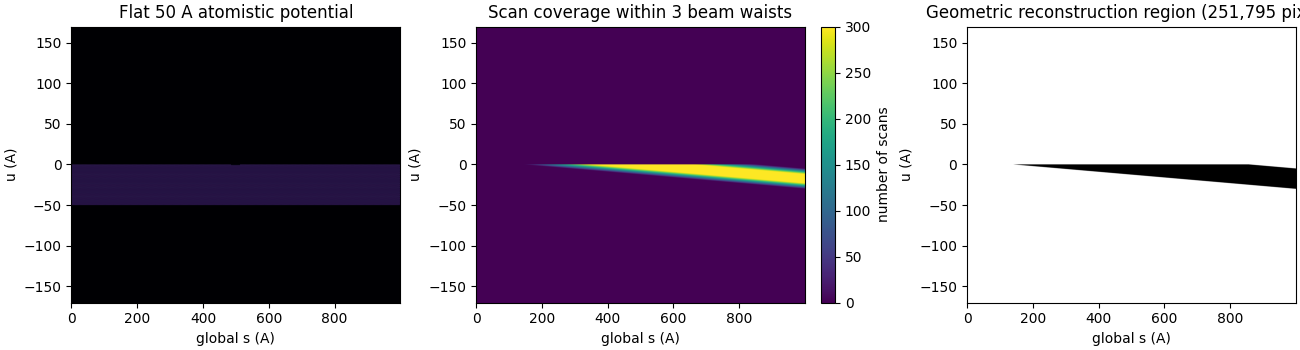

In [69]:
if reconstruction_mask is not None:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
    extent = [s_A[0], s_A[-1], u_A[0], u_A[-1]]
    axes[0].imshow(
        ground_truth_potential.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="magma",
    )
    axes[0].set_title("Flat 50 A atomistic potential")
    coverage_image = axes[1].imshow(
        beam_path_scan_coverage.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
    )
    axes[1].set_title(
        f"Scan coverage within {BEAM_PATH_RADIUS_WAISTS:g} beam waists"
    )
    fig.colorbar(coverage_image, ax=axes[1], label="number of scans")
    axes[2].imshow(
        reconstruction_mask.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="gray_r",
    )
    axes[2].set_title(
        f"Geometric reconstruction region ({reconstruction_mask.sum():,} pixels)"
    )
    for ax in axes:
        ax.set_xlabel("global s (A)")
        ax.set_ylabel("u (A)")
    plt.show()

## Noiseless diffraction dataset and region-truncation diagnostic

The measured stack is generated from the complete 50 Å slab. We also compare it with scattering from only the geometric reconstruction region. That amplitude NRMSE is a model-mismatch warning: it says how much measured scattering the chosen finite region omits, but it does not redefine the region automatically.

In [70]:
def simulate_in_chunks(potential, starts, batch_size=PREDICTION_BATCH_SIZE):
    chunks = []
    for begin in range(0, len(starts), batch_size):
        chunks.append(
            simulate_glancing_scan_1d(
                jnp.asarray(potential),
                input_probes[begin : begin + batch_size],
                jnp.asarray(starts[begin : begin + batch_size]),
                window_length,
                angular_spectrum_kernel,
                ds,
                energy_eV,
                rematerialize=False,
            )
        )
    return jnp.concatenate(chunks, axis=0)

def amplitude_nrmse(predicted, reference, epsilon=1e-12):
    predicted_amplitude = np.sqrt(np.asarray(predicted) + epsilon)
    reference_amplitude = np.sqrt(np.asarray(reference) + epsilon)
    return np.linalg.norm(predicted_amplitude - reference_amplitude) / np.linalg.norm(reference_amplitude)

measured_intensities = None
scan = None
if RUN_DATA_SIMULATION:
    if reconstruction_mask is None:
        raise RuntimeError("Enable region design before data simulation.")
    measured_intensities = simulate_in_chunks(ground_truth_potential, window_starts)
    masked_truth = np.where(reconstruction_mask, ground_truth_potential, 0.0)
    masked_intensities = simulate_in_chunks(masked_truth, window_starts)
    region_truncation_nrmse = amplitude_nrmse(masked_intensities, measured_intensities)
    print(f"Geometric-region truncation amplitude NRMSE: {region_truncation_nrmse:.3e}")
    if region_truncation_nrmse >= 1e-4:
        print(
            "WARNING: the selected beam-path region omits measurable scattering. "
            "Increase BEAM_PATH_RADIUS_WAISTS or interpret reconstruction "
            "residuals as including this model mismatch."
        )

    scan = GlancingScan1D(
        intensities=measured_intensities,
        window_starts=jnp.asarray(window_starts),
        scan_coordinates=jnp.asarray(scan_coordinates_A),
        detector_angles=jnp.asarray(detector_angles_mrad),
        metadata={
            "energy_eV": energy_eV,
            "propagation_model": "Angular spectrum",
            "glancing_angle_deg": glancing_angle_deg,
            "slab_depth_A": slab_depth_A,
            "beam_path_radius_waists": BEAM_PATH_RADIUS_WAISTS,
            "minimum_scan_coverage": MINIMUM_SCAN_COVERAGE,
            "region_truncation_amplitude_nrmse": region_truncation_nrmse,
            "data_to_unknown_ratio": data_to_unknown_ratio,
            "validation_indices": validation_indices.tolist(),
        },
    )
    if SAVE_RESULTS:
        result_dir.mkdir(parents=True, exist_ok=True)
        save_glancing_scan_1d(result_dir / "noiseless_scan.npz", scan)
else:
    print("Dataset simulation disabled; set RUN_DATA_SIMULATION = True.")

Geometric-region truncation amplitude NRMSE: 1.042e-01


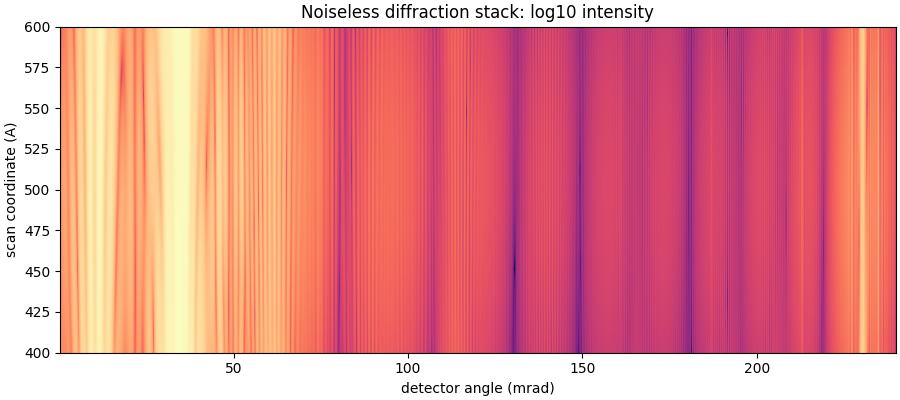

In [71]:
if measured_intensities is not None:
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    ax.imshow(
        np.log10(
            np.asarray(measured_intensities)[:, positive_detector_mask] + 1e-30
        ),
        origin="lower",
        aspect="auto",
        extent=[
            positive_detector_angles_mrad[0],
            positive_detector_angles_mrad[-1],
            scan_coordinates_A[0],
            scan_coordinates_A[-1],
        ],
        cmap="magma",
    )
    ax.set_xlabel("detector angle (mrad)")
    ax.set_ylabel("scan coordinate (A)")
    ax.set_title("Noiseless diffraction stack: log10 intensity")
    plt.show()

## Stored side views

Every scan is rerun once with internal-field output, so the viewer can advance one scan position at a time without recomputing a side view. Complex fields are block-averaged by 8×2; intensity is averaged independently so its display is not obtained by squaring an averaged complex field.

In [72]:
def selected_sideview_indices(n_scan):
    return np.unique(
        np.concatenate(
            [
                np.arange(0, n_scan, SIDEVIEW_SCAN_STRIDE, dtype=np.int32),
                np.asarray([0, n_scan - 1], dtype=np.int32),
            ]
        )
    )

truth_sideview_cache = None
if RUN_TRUTH_SIDEVIEWS:
    if measured_intensities is None:
        raise RuntimeError("Run the diffraction simulation before caching side views.")
    truth_sideview_cache = simulate_glancing_sideview_cache_1d(
        jnp.asarray(ground_truth_potential),
        input_probes,
        jnp.asarray(window_starts),
        window_length,
        angular_spectrum_kernel,
        ds,
        energy_eV,
        jnp.asarray(selected_sideview_indices(len(window_starts))),
        transverse_coordinates=jnp.asarray(u_A),
        scan_coordinates=jnp.asarray(scan_coordinates_A),
        axial_stride=SIDEVIEW_AXIAL_STRIDE,
        transverse_stride=SIDEVIEW_TRANSVERSE_STRIDE,
        metadata={"potential_source": "ground_truth", "model": "Angular spectrum"},
    )
    if SAVE_RESULTS:
        result_dir.mkdir(parents=True, exist_ok=True)
        save_glancing_sideview_cache_1d(
            result_dir / "ground_truth_sideviews.npz",
            truth_sideview_cache,
        )
else:
    print("Truth side-view generation disabled; set RUN_TRUTH_SIDEVIEWS = True.")

## Direct potential reconstruction

Every selected mask pixel is independent. The initial potential is weak and uniform and contains no atomic lattice modulation.

In [73]:
reconstruction = None
if RUN_RECONSTRUCTION:
    if measured_intensities is None or reconstruction_mask is None:
        raise RuntimeError("Run region design and dataset simulation first.")

    positive_bulk = ground_truth_potential[ground_truth_potential > 0]
    potential_scale_V = float(np.mean(positive_bulk))
    potential_max_V = 1.25 * float(np.max(positive_bulk))
    phase_bound = float(interaction_constant(energy_eV)) * ds * potential_max_V
    if phase_bound >= np.pi:
        raise RuntimeError(
            f"Per-slice phase bound is {phase_bound:.3f} rad; refine ds before reconstruction."
        )

    rng = np.random.default_rng(0)
    initial_values = 0.05 * potential_scale_V * (
        1.0 + 0.01 * rng.standard_normal(reconstruction_mask.shape)
    )
    initial_potential = np.where(
        reconstruction_mask,
        np.clip(initial_values, 0.0, potential_max_V),
        0.0,
    )

    reconstruction = reconstruct_potential_1d(
        jnp.asarray(initial_potential),
        jnp.asarray(reconstruction_mask),
        input_probes,
        jnp.asarray(window_starts),
        window_length,
        angular_spectrum_kernel,
        ds,
        energy_eV,
        measured_intensities,
        axial_coordinates=jnp.asarray(s_A),
        transverse_coordinates=jnp.asarray(u_A),
        scan_coordinates=jnp.asarray(scan_coordinates_A),
        detector_angles=jnp.asarray(detector_angles_mrad),
        validation_indices=validation_indices,
        potential_scale=potential_scale_V,
        potential_max=potential_max_V,
        updates=4000,
        minibatch_size=5,
        validation_interval=100,
        evaluation_batch_size=PREDICTION_BATCH_SIZE,
        rematerialize=True,
        seed=0,
    )
    if SAVE_RESULTS:
        result_dir.mkdir(parents=True, exist_ok=True)
        save_potential_reconstruction_1d(
            result_dir / "potential_reconstruction.npz",
            reconstruction,
        )
else:
    print("Reconstruction disabled; set RUN_RECONSTRUCTION = True.")

Reconstruction disabled; set RUN_RECONSTRUCTION = True.


In [74]:
if reconstruction is not None:
    truth_supported = np.where(reconstruction_mask, ground_truth_potential, 0.0)
    recovered = np.asarray(reconstruction.potential)
    error = recovered - truth_supported
    extent = [s_A[0], s_A[-1], u_A[0], u_A[-1]]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    vmax = np.percentile(truth_supported[reconstruction_mask], 99.5)
    for ax, image, title in zip(
        axes,
        [truth_supported, recovered, error],
        ["True supported potential", "Recovered potential", "Error"],
    ):
        im = ax.imshow(
            image.T,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="coolwarm" if title == "Error" else "magma",
            vmin=-vmax if title == "Error" else 0,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("s (A)")
        ax.set_ylabel("u (A)")
        fig.colorbar(im, ax=ax)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
    ax.semilogy(reconstruction.update_history, reconstruction.training_loss_history, label="training")
    ax.semilogy(reconstruction.update_history, reconstruction.validation_loss_history, label="validation")
    ax.axvline(reconstruction.best_update, color="k", linestyle=":", label="best")
    ax.set_xlabel("optimizer update")
    ax.set_ylabel("normalized amplitude loss")
    ax.legend()
    plt.show()

In [75]:
def depth_band_metrics(truth, recovered, mask, u_coordinates, band_width_A=5.0):
    rows = []
    for shallow in np.arange(0.0, slab_depth_A, band_width_A):
        deep = shallow + band_width_A
        band = mask & (u_coordinates[None, :] <= -shallow) & (u_coordinates[None, :] > -deep)
        if band.sum() < 2:
            continue
        truth_values = truth[band]
        recovered_values = recovered[band]
        correlation = np.corrcoef(truth_values, recovered_values)[0, 1]
        nrmse = np.linalg.norm(recovered_values - truth_values) / np.linalg.norm(truth_values)
        rows.append((shallow, deep, int(band.sum()), correlation, nrmse))
    return rows

if reconstruction is not None:
    depth_metrics = depth_band_metrics(
        ground_truth_potential,
        np.asarray(reconstruction.potential),
        reconstruction_mask,
        u_A,
    )
    print("depth range A | pixels | correlation | potential NRMSE")
    for shallow, deep, count, correlation, nrmse in depth_metrics:
        print(f"{shallow:4.0f}-{deep:4.0f} | {count:7d} | {correlation:10.4f} | {nrmse:10.4f}")

In [76]:
reconstructed_sideview_cache = None
if RUN_RECONSTRUCTED_SIDEVIEWS:
    if reconstruction is None:
        raise RuntimeError("Run the reconstruction before caching reconstructed side views.")
    reconstructed_sideview_cache = simulate_glancing_sideview_cache_1d(
        reconstruction.potential,
        input_probes,
        jnp.asarray(window_starts),
        window_length,
        angular_spectrum_kernel,
        ds,
        energy_eV,
        jnp.asarray(selected_sideview_indices(len(window_starts))),
        transverse_coordinates=jnp.asarray(u_A),
        scan_coordinates=jnp.asarray(scan_coordinates_A),
        axial_stride=SIDEVIEW_AXIAL_STRIDE,
        transverse_stride=SIDEVIEW_TRANSVERSE_STRIDE,
        metadata={"potential_source": "reconstructed", "model": "Angular spectrum"},
    )
    if SAVE_RESULTS:
        save_glancing_sideview_cache_1d(
            result_dir / "reconstructed_sideviews.npz",
            reconstructed_sideview_cache,
        )
else:
    print("Reconstructed side-view generation disabled.")

Reconstructed side-view generation disabled.


## Static and interactive scan viewer

A single scan-position slider controls the viewer. Cached positions render immediately; enable `include uncached positions` to expose every scan, in which case an uncached selection is propagated once and retained in a four-entry in-memory cache. The detector panel displays only positive diffraction angles, excluding the transmitted beam at zero angle. The main side view uses global specimen coordinates and fixed display limits, so the beam visibly translates as the surface landing coordinate changes. Interactive zoom and pan require the `ipympl` package; `%matplotlib widget` must run before importing `matplotlib.pyplot`.

In [77]:
_on_demand_cache = OrderedDict()

def _single_scan_cache(scan_index, potential, potential_source):
    key = (int(scan_index), potential_source)
    if key not in _on_demand_cache:
        value = simulate_glancing_sideview_cache_1d(
            jnp.asarray(potential),
            input_probes,
            jnp.asarray(window_starts),
            window_length,
            angular_spectrum_kernel,
            ds,
            energy_eV,
            jnp.asarray([scan_index]),
            transverse_coordinates=jnp.asarray(u_A),
            scan_coordinates=jnp.asarray(scan_coordinates_A),
            axial_stride=SIDEVIEW_AXIAL_STRIDE,
            transverse_stride=SIDEVIEW_TRANSVERSE_STRIDE,
        )
        _on_demand_cache[key] = value
        while len(_on_demand_cache) > 4:
            _on_demand_cache.popitem(last=False)
    return _on_demand_cache[key]

def _cache_row(cache, scan_index):
    indices = np.asarray(cache.scan_indices)
    matches = np.flatnonzero(indices == scan_index)
    return int(matches[0]) if matches.size else None

def _display_maximum(arrays, fallback=1.0):
    maxima = [float(np.max(np.asarray(array))) for array in arrays if array is not None]
    return max([*maxima, float(fallback), 1e-30])

_sideview_display_max = _display_maximum(
    [
        cache.sideview_intensities
        for cache in (truth_sideview_cache, reconstructed_sideview_cache)
        if cache is not None
    ],
    fallback=np.max(np.abs(np.asarray(input_probe)) ** 2),
)
_exit_display_max = _display_maximum(
    [
        np.abs(np.asarray(cache.exit_waves)) ** 2
        for cache in (truth_sideview_cache, reconstructed_sideview_cache)
        if cache is not None
    ]
)
_detector_display_max = _display_maximum(
    [
        (
            measured_intensities[:, positive_detector_mask]
            if measured_intensities is not None
            else None
        ),
        *(
            cache.detector_intensities[..., positive_detector_mask]
            for cache in (truth_sideview_cache, reconstructed_sideview_cache)
            if cache is not None
        ),
    ]
)

def plot_scan_diagnostics(
    scan_index,
    potential_source="ground truth",
    allow_recompute=True,
    fig=None,
):
    scan_index = int(scan_index)
    if potential_source == "reconstructed":
        if reconstruction is None:
            raise RuntimeError("No reconstruction is available.")
        potential = np.asarray(reconstruction.potential)
        cache = reconstructed_sideview_cache
    else:
        potential = ground_truth_potential
        cache = truth_sideview_cache

    row = _cache_row(cache, scan_index) if cache is not None else None
    if row is None:
        if not allow_recompute:
            raise ValueError(f"Scan {scan_index} is not stored in the selected cache.")
        cache = _single_scan_cache(scan_index, potential, potential_source)
        row = 0

    side_intensity = np.asarray(cache.sideview_intensities[row])
    side_field = np.asarray(cache.sideview_wavefields[row])
    exit_intensity = np.abs(np.asarray(cache.exit_waves[row])) ** 2
    detector_intensity = np.asarray(cache.detector_intensities[row])
    start_A = float(window_starts[scan_index] * ds)
    surface_coordinate_A = float(scan_coordinates_A[scan_index])
    side_s_A = start_A + np.asarray(cache.local_s_coordinates)
    side_u_A = np.asarray(cache.sideview_u_coordinates)
    beam_centreline_u_A = np.tan(input_tilt_rad) * (
        side_s_A - surface_coordinate_A
    )
    fixed_side_intensity = np.full(
        (n_global_s, side_intensity.shape[1]),
        np.nan,
        dtype=side_intensity.dtype,
    )
    for block_index, intensity_column in enumerate(side_intensity):
        block_start = int(window_starts[scan_index]) + (
            block_index * SIDEVIEW_AXIAL_STRIDE
        )
        block_stop = min(
            block_start + SIDEVIEW_AXIAL_STRIDE,
            n_global_s,
        )
        fixed_side_intensity[block_start:block_stop] = intensity_column
    fixed_side_intensity = np.ma.masked_invalid(fixed_side_intensity)

    if fig is None:
        with plt.ioff():
            fig = plt.figure(figsize=(14, 6.5), constrained_layout=True)
    else:
        fig.clear()
        fig.set_constrained_layout(True)
    grid = fig.add_gridspec(2, 2, width_ratios=(2.25, 1.0))
    side = fig.add_subplot(grid[:, 0])
    exit_ax = fig.add_subplot(grid[0, 1])
    detector_ax = fig.add_subplot(grid[1, 1])

    potential_peak = float(np.max(potential))
    if potential_peak > 0.0:
        potential_cmap = plt.get_cmap("plasma").copy()
        potential_cmap.set_bad(alpha=0.0)
        side.imshow(
            np.ma.masked_where(potential.T <= 0.0, potential.T),
            origin="lower",
            aspect="auto",
            extent=[s_A[0], s_A[-1], u_A[0], u_A[-1]],
            cmap=potential_cmap,
            norm=PowerNorm(gamma=0.5, vmin=0.0, vmax=potential_peak),
            alpha=0.50,
            zorder=2,
        )
    intensity_cmap = plt.get_cmap("viridis").copy()
    intensity_cmap.set_bad(alpha=0.0)
    side_image = side.imshow(
        fixed_side_intensity.T,
        origin="lower",
        aspect="auto",
        extent=[
            s_A[0],
            s_A[-1],
            side_u_A[0],
            side_u_A[-1],
        ],
        cmap=intensity_cmap,
        norm=PowerNorm(
            gamma=0.5,
            vmin=0.0,
            vmax=_sideview_display_max,
        ),
        zorder=1,
    )
    side.plot(
        side_s_A,
        beam_centreline_u_A,
        color="white",
        linestyle="--",
        linewidth=1.2,
        label="nominal beam centreline",
    )
    side.scatter(
        [surface_coordinate_A],
        [0.0],
        s=45,
        color="cyan",
        edgecolor="black",
        linewidth=0.6,
        zorder=4,
        label="surface landing position",
    )
    side.axhline(0.0, color="cyan", linewidth=0.8, alpha=0.8)
    side.axhline(-slab_depth_A, color="cyan", linewidth=0.8, alpha=0.8)
    side.set_xlim(float(s_A[0]), float(s_A[-1]))
    side.set_ylim(-75.0, 100.0)
    side.set(
        title=f"Scan {scan_index}: beam landing at s = {surface_coordinate_A:.2f} A",
        xlabel="global specimen coordinate s (A)",
        ylabel="u (A)",
    )
    side.legend(loc="lower left")
    fig.colorbar(side_image, ax=side, label="intensity")

    exit_mask = u_A > 0.0
    exit_ax.plot(u_A[exit_mask], exit_intensity[exit_mask])
    exit_ax.set_xlim(0.0, float(u_A[-1]))
    exit_ax.set(title="Exit-wave intensity", xlabel="u (A)", ylabel="intensity")

    detector_ax.plot(
        positive_detector_angles_mrad,
        detector_intensity[positive_detector_mask] + 1e-30,
        label=potential_source,
    )
    if potential_source == "reconstructed" and reconstruction is not None:
        detector_ax.plot(
            positive_detector_angles_mrad,
            np.asarray(reconstruction.measured_intensities[scan_index])[
                positive_detector_mask
            ]
            + 1e-30,
            color="k",
            alpha=0.55,
            label="measured",
        )
    detector_ax.set(title="Recorded far field", xlabel="detector angle (mrad)", ylabel="intensity")
    detector_ax.legend()

    fig.suptitle(
        f"{potential_source}; scan coordinate {surface_coordinate_A:.2f} A; "
        f"stored phase range {np.ptp(np.angle(side_field)):.2f} rad"
    )
    return fig

In [78]:
available_cache = (
    truth_sideview_cache
    if truth_sideview_cache is not None
    else reconstructed_sideview_cache
)
if available_cache is not None:
    cached_indices = tuple(int(value) for value in np.asarray(available_cache.scan_indices))
    try:
        import ipywidgets as widgets
        from IPython.display import display

        def scan_options(indices):
            return tuple(
                (f"{index:03d} — {scan_coordinates_A[index]:8.2f} A", index)
                for index in indices
            )

        cached_options = scan_options(cached_indices)
        all_options = scan_options(range(len(window_starts)))
        scan_selector = widgets.SelectionSlider(
            options=cached_options,
            value=cached_indices[0],
            description="scan position",
            continuous_update=False,
            style={"description_width": "initial"},
            layout=widgets.Layout(width="720px"),
        )
        include_uncached = widgets.Checkbox(
            value=False,
            description="include uncached positions (recompute on selection)",
            indent=False,
            style={"description_width": "initial"},
        )
        sources = ["ground truth"]
        if reconstruction is not None:
            sources.append("reconstructed")
        source_selector = widgets.ToggleButtons(options=sources, description="potential")

        def update_scan_options(change):
            previous = int(scan_selector.value)
            indices = range(len(window_starts)) if change["new"] else cached_indices
            nearest = min(indices, key=lambda index: abs(index - previous))
            with scan_selector.hold_trait_notifications():
                scan_selector.options = all_options if change["new"] else cached_options
                scan_selector.value = nearest

        include_uncached.observe(update_scan_options, names="value")

        rendered_fig = [None]

        def render(scan_index, potential_source):
            if rendered_fig[0] is None:
                rendered_fig[0] = plot_scan_diagnostics(
                    scan_index, potential_source, allow_recompute=True
                )
            else:
                plot_scan_diagnostics(
                    scan_index,
                    potential_source,
                    allow_recompute=True,
                    fig=rendered_fig[0],
                )
                rendered_fig[0].canvas.draw_idle()

        scan_selector.observe(
            lambda change: render(scan_selector.value, source_selector.value),
            names="value",
        )
        source_selector.observe(
            lambda change: render(scan_selector.value, source_selector.value),
            names="value",
        )
        controls = widgets.VBox([scan_selector, include_uncached, source_selector])
        render(scan_selector.value, source_selector.value)
        display(widgets.VBox([controls, rendered_fig[0].canvas]))
    except ImportError:
        for index in (cached_indices[0], cached_indices[len(cached_indices) // 2], cached_indices[-1]):
            plot_scan_diagnostics(index, allow_recompute=False)
            plt.show()
            plt.close()
else:
    print("Generate or load a side-view cache to enable the viewer.")

## Interpretation

The inverse model is intentionally free at every potential pixel in the chosen geometric beam-path region. Inclusion means only that a pixel lies near one or more nominal beam paths; it does not guarantee identifiability. The depth-band table and repeat-seed agreement determine how much of the nominal 50 Å slab is actually recovered. Stored side views are diagnostic products only; reconstruction continues to use the wavefield-free batched forward path.